In [1]:
import pandas as pd

df = pd.read_csv("data/Emotion.csv")
df.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21459 entries, 0 to 21458
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     21459 non-null  object
 1   Emotion  21459 non-null  object
dtypes: object(2)
memory usage: 335.4+ KB


In [3]:
df.shape

(21459, 2)

In [4]:
df.columns

Index(['Text', 'Emotion'], dtype='object')

In [5]:
df.columns = ['text', 'emotion']

In [6]:
df = df.dropna()

df['text'] = df['text'].str.lower()
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
df['emotion'].value_counts()

emotion
happy       7029
sadness     6265
anger       2993
fear        2652
love        1641
surprise     879
Name: count, dtype: int64

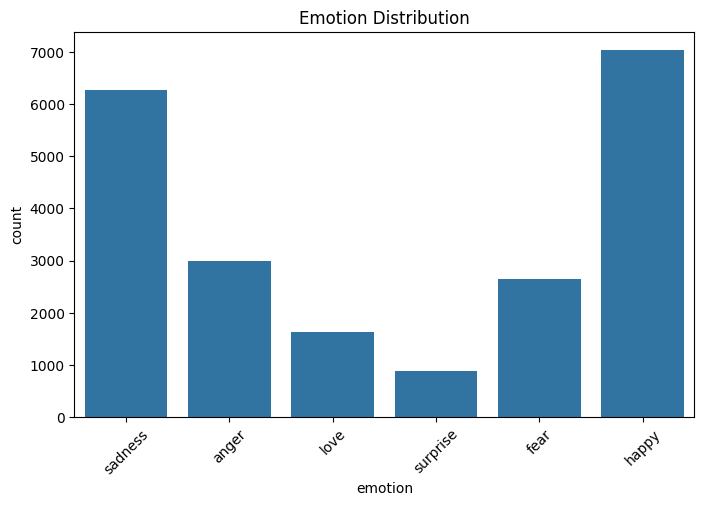

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='emotion', data=df)
plt.xticks(rotation=45)
plt.title("Emotion Distribution")
plt.show()

In [9]:
df['text_length'] = df['text'].apply(len)

df[['text', 'text_length']].head()

,text,text_length
0,i didnt feel humiliated,23
1,i can go from feeling so hopeless to so damned...,108
2,im grabbing a minute to post i feel greedy wrong,48
3,i am ever feeling nostalgic about the fireplac...,92
4,i am feeling grouchy,20


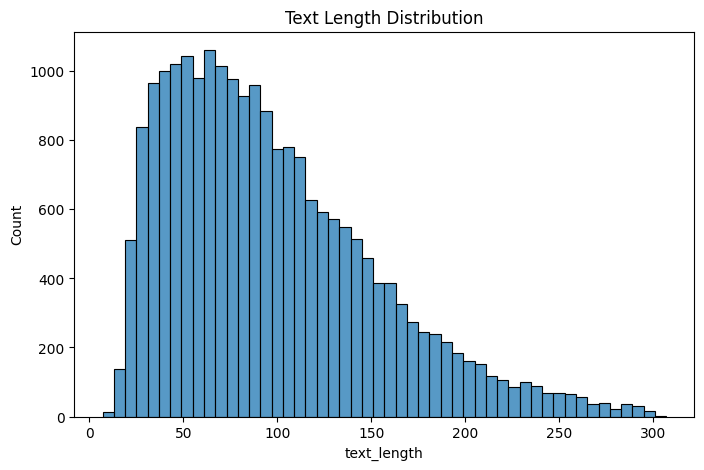

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [11]:
df.groupby('emotion')['text_length'].mean().sort_values()

emotion
sadness      93.298484
anger        96.301704
fear         96.341252
surprise     97.916951
happy        98.269455
love        103.778793
Name: text_length, dtype: float64

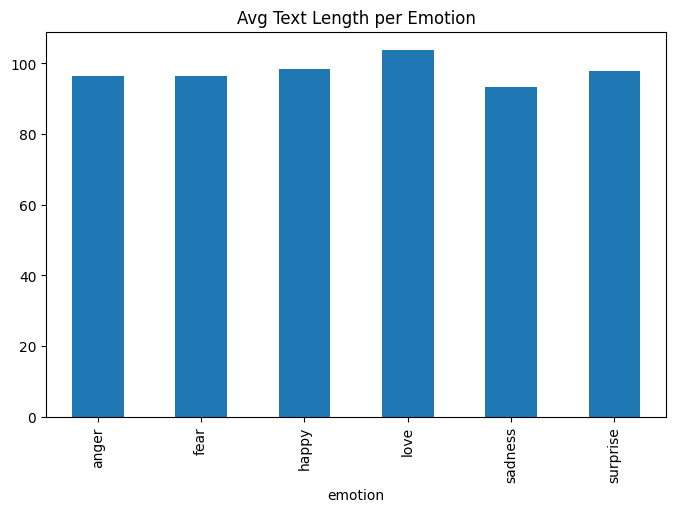

In [12]:
df.groupby('emotion')['text_length'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Avg Text Length per Emotion")
plt.show()

In [13]:
from collections import Counter

all_words = " ".join(df['text']).split()

common_words = Counter(all_words).most_common(20)

common_words

[('i', 32529),
 ('feel', 13973),
 ('and', 12721),
 ('to', 11835),
 ('the', 11808),
 ('a', 8333),
 ('of', 6823),
 ('that', 6540),
 ('feeling', 6461),
 ('my', 5422),
 ('in', 4677),
 ('it', 4087),
 ('like', 3659),
 ('was', 3279),
 ('so', 3210),
 ('for', 3189),
 ('im', 3055),
 ('but', 2948),
 ('me', 2942),
 ('have', 2887)]

In [14]:
for emotion in df['emotion'].unique():
    words = " ".join(df[df['emotion']==emotion]['text']).split()
    common = Counter(words).most_common(5)
    print(f"\n{emotion}: {common}")


sadness: [('i', 9556), ('feel', 4095), ('and', 3633), ('to', 3141), ('the', 3097)]

anger: [('i', 4531), ('feel', 1803), ('and', 1708), ('the', 1628), ('to', 1566)]

love: [('i', 2641), ('feel', 1180), ('and', 1119), ('to', 1049), ('the', 969)]

surprise: [('i', 1188), ('the', 567), ('and', 518), ('feel', 464), ('to', 406)]

fear: [('i', 3824), ('the', 1510), ('to', 1488), ('feel', 1483), ('and', 1471)]

happy: [('i', 10789), ('feel', 4948), ('and', 4272), ('to', 4185), ('the', 4037)]


In [15]:
df.isnull().sum()

text           0
emotion        0
text_length    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(3)

In [17]:
df = df.drop_duplicates()

In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text','clean_text']].head()

,text,clean_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy


In [19]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['clean_text'])  # 🔥 important
y = df['emotion']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [30]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

nb = MultinomialNB()
nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    
    print(f"\n{name} Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


Logistic Regression Accuracy: 0.874650512581547

Classification Report:

              precision    recall  f1-score   support

       anger       0.90      0.81      0.85       599
        fear       0.89      0.82      0.85       530
       happy       0.85      0.96      0.90      1406
        love       0.87      0.67      0.76       328
     sadness       0.89      0.94      0.92      1253
    surprise       0.85      0.53      0.66       176

    accuracy                           0.87      4292
   macro avg       0.88      0.79      0.82      4292
weighted avg       0.88      0.87      0.87      4292



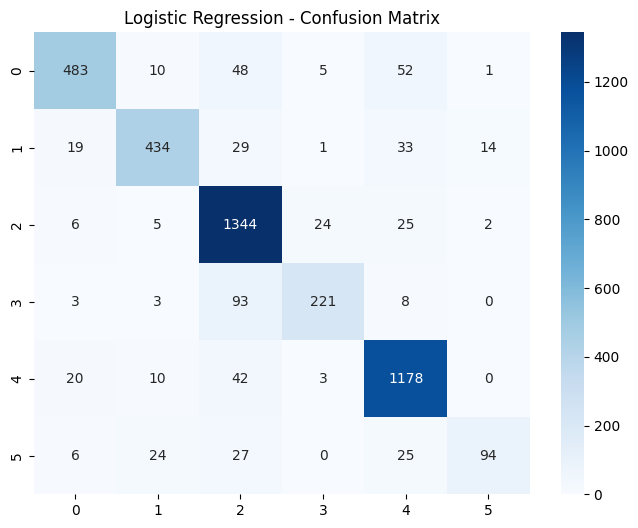


Naive Bayes Accuracy: 0.7758620689655172

Classification Report:

              precision    recall  f1-score   support

       anger       0.92      0.61      0.73       599
        fear       0.90      0.61      0.73       530
       happy       0.72      0.97      0.83      1406
        love       0.99      0.25      0.40       328
     sadness       0.76      0.94      0.84      1253
    surprise       1.00      0.07      0.14       176

    accuracy                           0.78      4292
   macro avg       0.88      0.58      0.61      4292
weighted avg       0.82      0.78      0.75      4292



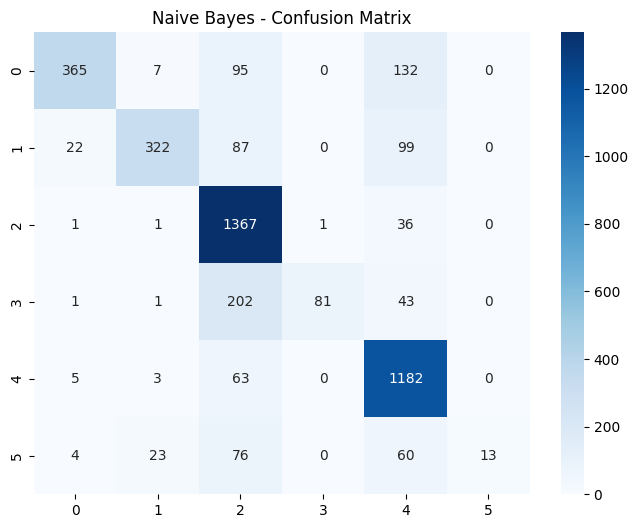

In [34]:
evaluate(lr, "Logistic Regression")
evaluate(nb, "Naive Bayes")

In [35]:
def predict_emotion(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    vector = vectorizer.transform([text])
    return lr.predict(vector)[0]

predict_emotion("I feel very lonely and stressed")

'sadness'

In [36]:
import pickle
import os

In [ ]:
os.makedirs("backend/model", exist_ok=True)

pickle.dump(lr, open("backend/model/emotion_model.pkl", "wb"))
pickle.dump(vectorizer, open("backend/model/vectorizer.pkl", "wb"))

In [ ]:
model_loaded = pickle.load(open("backend/model/emotion_model.pkl", "rb"))
vectorizer_loaded = pickle.load(open("backend/model/vectorizer.pkl", "rb"))